# 09C｜門檻校準與獨立測試

使用 09B 切分的兩組資料，驗證一個在 FF++ 上訓練的模型，其預設分類門檻在訓練分布外是否仍然適用。

```text
dataset_mobile_split/
├── calibration/   Real 50、Fake 50
└── test/          Real 100、Fake 100
```

執行原則：

1. 只使用 `calibration` 搜尋 Fake F1 最高的門檻。
2. 門檻選定後固定，不再依正式測試結果調整。
3. 最後才在獨立的 `test` 上比較預設門檻 0.5 與校準門檻。
4. 不重新訓練或微調模型，僅改變機率的切分位置。

**資料限制**：Real 為手機實拍、Fake 為網路蒐集，兩類來源不同，AUC 數值不作為泛化能力的估計（詳見 09A）。本節的結論建立在機率分布的形狀上，與 AUC 的絕對值無關。

## 1. 匯入套件與中文字型設定

In [1]:
from pathlib import Path
import hashlib
import json
import os
import platform
import random
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm


def setup_chinese_font():
    system = platform.system()
    if system == "Windows":
        candidates = ["Microsoft JhengHei", "Microsoft YaHei", "SimHei"]
    elif system == "Darwin":
        candidates = ["PingFang TC", "Heiti TC", "Arial Unicode MS"]
    else:
        candidates = [
            "Noto Sans CJK TC",
            "Noto Sans CJK SC",
            "WenQuanYi Zen Hei",
        ]
    plt.rcParams["font.sans-serif"] = candidates + ["DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False


setup_chinese_font()
print("Python：", sys.version.split()[0])
print("PyTorch：", torch.__version__)
print("CUDA 可用：", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU：", torch.cuda.get_device_name(0))


Python： 3.10.19
PyTorch： 2.5.1+cu121
CUDA 可用： True
GPU： NVIDIA GeForce RTX 4070


## 2. 設定

`ORIGINAL_THRESHOLD` 為模型預設的 0.5，作為比較基準。校準集與測試集的數量在正式執行時不應更動。

In [2]:
FORENSICS_ADAPTER_DIR = Path("./ForensicsAdapter")
CLIP_WEIGHTS_DIR = Path("./ForensicsAdapter_Weights")
BEST_MODEL_PATH = Path(
    "./ForensicsAdapter_Results/"
    "ffpp_original_deepfakes_full/best_model.pth"
)

MOBILE_SPLIT_ROOT = Path("./dataset_mobile_split")
CALIBRATION_ROOT = MOBILE_SPLIT_ROOT / "calibration"
FORMAL_TEST_ROOT = MOBILE_SPLIT_ROOT / "test"

OUTPUT_ROOT = Path(
    "./ForensicsAdapter_Results/"
    "ffpp_original_deepfakes_mobile_threshold_calibration"
)

IMAGE_SIZE = 256
BATCH_SIZE = 4
NUM_WORKERS = 0
SEED = 42

ORIGINAL_THRESHOLD = 0.5
THRESHOLD_MIN = 0.01
THRESHOLD_MAX = 0.99
THRESHOLD_STEP = 0.001

EXPECTED_COUNTS = {
    ("calibration", "real"): 50,
    ("calibration", "fake"): 50,
    ("test", "real"): 100,
    ("test", "fake"): 100,
}

RUN_CALIBRATION = True
RUN_FORMAL_TEST = True

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
PIN_MEMORY = DEVICE.type == "cuda"

print("官方專案：", FORENSICS_ADAPTER_DIR.resolve())
print("最佳模型：", BEST_MODEL_PATH.resolve())
print("手機切分資料：", MOBILE_SPLIT_ROOT.resolve())
print("輸出：", OUTPUT_ROOT.resolve())
print("裝置：", DEVICE)


官方專案： D:\資料\專題\PY\deepfake\新版專題研究\ForensicsAdapter
最佳模型： D:\資料\專題\PY\deepfake\新版專題研究\ForensicsAdapter_Results\ffpp_original_deepfakes_full\best_model.pth
手機切分資料： D:\資料\專題\PY\deepfake\新版專題研究\dataset_mobile_split
輸出： D:\資料\專題\PY\deepfake\新版專題研究\ForensicsAdapter_Results\ffpp_original_deepfakes_mobile_threshold_calibration
裝置： cuda:0


## 3. 固定亂數與檢查必要檔案

In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

required_files = [
    FORENSICS_ADAPTER_DIR / "model" / "ds.py",
    FORENSICS_ADAPTER_DIR / "model" / "adapters" / "adapter.py",
    BEST_MODEL_PATH,
]
missing = [str(path.resolve()) for path in required_files if not path.is_file()]
if missing:
    raise FileNotFoundError("缺少必要檔案：\n" + "\n".join(missing))

for split_name, split_root in (
    ("calibration", CALIBRATION_ROOT),
    ("test", FORMAL_TEST_ROOT),
):
    for class_name in ("real", "fake"):
        class_dir = split_root / class_name
        if not class_dir.is_dir():
            raise FileNotFoundError(
                f"缺少資料夾：{class_dir.resolve()}"
            )

CLIP_WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
if DEVICE.type != "cuda":
    print("提醒：目前使用 CPU，ViT-L/14 推論會非常慢。")
print("必要檔案與資料夾檢查完成。")


必要檔案與資料夾檢查完成。


## 4. 掃描資料並檢查兩組資料互斥

除了數量，另以 SHA-256 確認校準集與測試集沒有共同圖片。若檢查失敗即中止——重疊會讓門檻選擇的資訊洩漏進評估結果。

In [4]:
IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"
}
LABEL_MAPPING = {"real": 0, "fake": 1}


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        while True:
            chunk = file.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def scan_split(split_name, root):
    records = []
    for class_name, label in LABEL_MAPPING.items():
        class_dir = root / class_name
        paths = sorted(
            path
            for path in class_dir.rglob("*")
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
        )
        expected = EXPECTED_COUNTS[(split_name, class_name)]
        if len(paths) != expected:
            raise ValueError(
                f"{split_name}/{class_name} 應有 {expected} 張，"
                f"目前是 {len(paths)} 張。"
            )

        for path in paths:
            records.append({
                "split": split_name,
                "path": str(path.resolve()),
                "file_name": path.name,
                "class_name": class_name,
                "label": label,
                "sha256": sha256_file(path),
            })

    return pd.DataFrame(records).sort_values(
        ["class_name", "file_name"]
    ).reset_index(drop=True)


calibration_df = scan_split("calibration", CALIBRATION_ROOT)
formal_test_df = scan_split("test", FORMAL_TEST_ROOT)

all_hashes = pd.concat(
    [
        calibration_df[["split", "path", "sha256"]],
        formal_test_df[["split", "path", "sha256"]],
    ],
    ignore_index=True,
)
duplicate_hashes = all_hashes[
    all_hashes.duplicated("sha256", keep=False)
].sort_values("sha256")
if not duplicate_hashes.empty:
    display(duplicate_hashes)
    raise ValueError("校準集與正式測試集發現內容相同的圖片。")

summary_df = pd.concat(
    [calibration_df, formal_test_df],
    ignore_index=True,
).groupby(["split", "class_name", "label"], as_index=False).size()
summary_df = summary_df.rename(columns={"size": "image_count"})
display(summary_df)
print("資料數量與互斥檢查通過。")


,split,class_name,label,image_count
0,calibration,fake,1,50
1,calibration,real,0,50
2,test,fake,1,100
3,test,real,0,100


資料數量與互斥檢查通過。


## 5. 建立資料集與 DataLoader

前處理完全沿用 07：

```text
YOLO 裁切後圖片 → RGB → 256×256 → CLIP mean/std Normalize
```

校準與測試皆不使用隨機資料增強。若前處理與訓練時不同，觀察到的機率偏移就無法歸因於資料分布。

In [5]:
CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
CLIP_STD = (0.26862954, 0.26130258, 0.27577711)
normalize = transforms.Normalize(CLIP_MEAN, CLIP_STD)


def imread_unicode(path, flags=cv2.IMREAD_COLOR):
    path_string = os.fspath(path)
    if (
        platform.system() == "Windows"
        and any(ord(character) > 127 for character in path_string)
    ):
        encoded = np.fromfile(path_string, dtype=np.uint8)
        if encoded.size == 0:
            return None
        return cv2.imdecode(encoded, flags)
    return cv2.imread(path_string, flags)


class MobileDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True).copy()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        path = Path(row["path"])
        image_bgr = imread_unicode(path, cv2.IMREAD_COLOR)
        if image_bgr is None:
            raise FileNotFoundError(f"無法讀取圖片：{path}")

        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        image_rgb = cv2.resize(
            image_rgb,
            (IMAGE_SIZE, IMAGE_SIZE),
            interpolation=cv2.INTER_CUBIC,
        )
        image = torch.from_numpy(
            image_rgb.transpose(2, 0, 1).copy()
        ).float().div(255.0)
        image = normalize(image)

        return {
            "image": image,
            "label": torch.tensor(int(row["label"]), dtype=torch.long),
            "if_boundary": torch.zeros(256, dtype=torch.long),
            "path": str(path),
            "file_name": str(row["file_name"]),
            "class_name": str(row["class_name"]),
            "split": str(row["split"]),
        }


def make_loader(dataframe):
    dataset = MobileDataset(dataframe)
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
    )
    return dataset, loader


calibration_dataset, calibration_loader = make_loader(calibration_df)
formal_test_dataset, formal_test_loader = make_loader(formal_test_df)
print(
    f"校準集：{len(calibration_dataset)} 張，"
    f"{len(calibration_loader)} batches"
)
print(
    f"正式測試集：{len(formal_test_dataset)} 張，"
    f"{len(formal_test_loader)} batches"
)


校準集：100 張，25 batches
正式測試集：200 張，50 batches


## 6. 載入 Forensics Adapter 與最佳權重

使用與 07、08 完全相同的架構與權重。權重檢查確認所有可訓練參數皆已還原。

In [6]:
ds_path = FORENSICS_ADAPTER_DIR / "model" / "ds.py"
ds_text = ds_path.read_text(encoding="utf-8")
hardcoded = "download_root='/data/cuixinjie/weights'"
replacement = f"download_root={str(CLIP_WEIGHTS_DIR.resolve())!r}"
if hardcoded in ds_text:
    backup_path = ds_path.with_suffix(".py.codex_backup")
    if not backup_path.exists():
        backup_path.write_text(ds_text, encoding="utf-8")
    ds_path.write_text(
        ds_text.replace(hardcoded, replacement),
        encoding="utf-8",
    )
    print("已將 CLIP 權重快取改為：", CLIP_WEIGHTS_DIR.resolve())
elif replacement not in ds_text:
    print(
        "提醒：ds.py 的 download_root 已被修改過，"
        "請確認它仍指向可用的 CLIP 權重資料夾。"
    )

project_path = str(FORENSICS_ADAPTER_DIR.resolve())
if project_path not in sys.path:
    sys.path.insert(0, project_path)

from model.ds import DS


model = DS(
    clip_name="ViT-L/14",
    adapter_vit_name="vit_tiny_patch16_224",
    num_quires=128,
    fusion_map={1: 1, 2: 8, 3: 15},
    mlp_dim=256,
    mlp_out_dim=128,
    head_num=16,
    device=DEVICE,
).to(DEVICE)

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False,
)
if "model_state_dict" not in checkpoint:
    raise KeyError(
        "best_model.pth 中找不到 model_state_dict，"
        "請確認使用 07 產生的最佳模型。"
    )

load_result = model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=False,
)
if load_result.unexpected_keys:
    raise RuntimeError(
        f"Checkpoint 含非預期參數：{load_result.unexpected_keys}"
    )

trainable_names = {
    name
    for name, parameter in model.named_parameters()
    if parameter.requires_grad
}
missing_trainable = sorted(
    trainable_names.intersection(load_result.missing_keys)
)
if missing_trainable:
    raise RuntimeError(
        "Checkpoint 缺少可訓練參數：\n"
        + "\n".join(missing_trainable)
    )

model.eval()
print("模型權重載入成功")
print("最佳 Epoch：", int(checkpoint.get("epoch", -1)) + 1)
print("最佳驗證 Video AUC：", checkpoint.get("best_val_auc", "未記錄"))
print("Checkpoint 參數數量：", len(checkpoint["model_state_dict"]))


width:1024 layers 24 
模型權重載入成功
最佳 Epoch： 5
最佳驗證 Video AUC： 0.9983163265306122
Checkpoint 參數數量： 207


## 7. 推論與指標函式

每個資料集只推論一次，得到 `P(Fake)` 後保存。不同門檻的分類結果皆由同一份機率重新計算，不重複推論——這也確保了門檻是唯一的變因。

In [7]:
def model_batch(batch):
    return {
        "image": batch["image"].to(DEVICE, non_blocking=True),
        "label": batch["label"].to(DEVICE, non_blocking=True),
        "if_boundary": batch["if_boundary"].to(
            DEVICE,
            non_blocking=True,
        ),
    }


def safe_auc(labels, probabilities):
    labels = np.asarray(labels, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    if np.unique(labels).size < 2:
        return float("nan")
    return float(roc_auc_score(labels, probabilities))


def binary_metrics(labels, probabilities, threshold):
    labels = np.asarray(labels, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    predictions = (probabilities >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0,
    )
    matrix = confusion_matrix(labels, predictions, labels=[0, 1])
    tn, fp, fn, tp = matrix.ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "sample_count": int(len(labels)),
        "real_count": int((labels == 0).sum()),
        "fake_count": int((labels == 1).sum()),
        "predicted_fake_count": int((predictions == 1).sum()),
        "accuracy": float(accuracy_score(labels, predictions)),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "f1": float(f1),
        "auc": safe_auc(labels, probabilities),
        "threshold": float(threshold),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def infer_dataset(model, dataloader, description):
    records = []
    model.eval()
    model.prob, model.label = [], []
    model.correct, model.total = 0, 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc=description):
            inputs = model_batch(batch)
            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=USE_AMP,
            ):
                pred = model(inputs, inference=True)
            probabilities = pred["prob"].detach().float().cpu()

            for index in range(len(probabilities)):
                records.append({
                    "split": batch["split"][index],
                    "path": batch["path"][index],
                    "file_name": batch["file_name"][index],
                    "class_name": batch["class_name"][index],
                    "label": int(batch["label"][index]),
                    "fake_probability": float(probabilities[index]),
                })

    model.prob, model.label = [], []
    model.correct, model.total = 0, 0
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return pd.DataFrame(records)


## 8. 使用校準集搜尋門檻

搜尋範圍 0.01–0.99，間隔 0.001。選擇規則在搜尋前固定：

1. Fake F1 最高。
2. F1 相同時，Accuracy 較高者優先。
3. 仍相同時，選擇較接近 0.5 的門檻。
4. 仍相同時，選擇數值較高者。

規則預先固定是為了避免事後從多個候選中挑選對結果有利的那一個。本節不讀取正式測試集的任何資料。

**選定門檻：0.463**

校準集上的表現：Accuracy 0.80、F1 0.80、AUC 0.838。

In [8]:
calibration_predictions_df = pd.DataFrame()
threshold_search_df = pd.DataFrame()
selected_threshold = None
calibration_metrics = {}

if not RUN_CALIBRATION:
    print("RUN_CALIBRATION=False，尚未執行門檻校準。")
else:
    calibration_predictions_df = infer_dataset(
        model,
        calibration_loader,
        "Calibration Inference",
    )
    calibration_predictions_df.to_csv(
        OUTPUT_ROOT / "calibration_predictions.csv",
        index=False,
        encoding="utf-8-sig",
    )

    thresholds = np.arange(
        THRESHOLD_MIN,
        THRESHOLD_MAX + THRESHOLD_STEP / 2,
        THRESHOLD_STEP,
    )
    threshold_records = [
        binary_metrics(
            calibration_predictions_df["label"],
            calibration_predictions_df["fake_probability"],
            threshold,
        )
        for threshold in thresholds
    ]
    threshold_search_df = pd.DataFrame(threshold_records)
    threshold_search_df["distance_to_0_5"] = (
        threshold_search_df["threshold"] - ORIGINAL_THRESHOLD
    ).abs()
    threshold_search_df = threshold_search_df.sort_values(
        ["f1", "accuracy", "distance_to_0_5", "threshold"],
        ascending=[False, False, True, False],
    ).reset_index(drop=True)

    selected_threshold = float(
        threshold_search_df.iloc[0]["threshold"]
    )
    calibration_metrics = binary_metrics(
        calibration_predictions_df["label"],
        calibration_predictions_df["fake_probability"],
        selected_threshold,
    )

    threshold_search_df.to_csv(
        OUTPUT_ROOT / "threshold_search.csv",
        index=False,
        encoding="utf-8-sig",
    )
    with (OUTPUT_ROOT / "selected_threshold.json").open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            {
                "selection_dataset": "mobile calibration set",
                "selection_metric": "Fake F1",
                "tie_breaking": [
                    "higher accuracy",
                    "closer to 0.5",
                    "higher threshold",
                ],
                "search_min": THRESHOLD_MIN,
                "search_max": THRESHOLD_MAX,
                "search_step": THRESHOLD_STEP,
                "selected_threshold": selected_threshold,
                "calibration_metrics": calibration_metrics,
            },
            file,
            ensure_ascii=False,
            indent=2,
        )

    print(f"選定門檻：{selected_threshold:.3f}")
    print(json.dumps(calibration_metrics, ensure_ascii=False, indent=2))
    display(threshold_search_df.head(10))


Calibration Inference:   0%|          | 0/25 [00:00<?, ?it/s]

選定門檻：0.463
{
  "sample_count": 100,
  "real_count": 50,
  "fake_count": 50,
  "predicted_fake_count": 50,
  "accuracy": 0.8,
  "precision": 0.8,
  "recall": 0.8,
  "specificity": 0.8,
  "f1": 0.8,
  "auc": 0.838,
  "threshold": 0.46299999999999963,
  "tn": 40,
  "fp": 10,
  "fn": 10,
  "tp": 40
}


,sample_count,real_count,fake_count,predicted_fake_count,accuracy,precision,recall,specificity,f1,auc,threshold,tn,fp,fn,tp,distance_to_0_5
0,100,50,50,50,0.80,0.800000,0.80,0.80,0.800000,0.838,0.463,40,10,10,40,0.037
1,100,50,50,48,0.80,0.812500,0.78,0.82,0.795918,0.838,0.465,41,9,11,39,0.035
2,100,50,50,48,0.80,0.812500,0.78,0.82,0.795918,0.838,0.464,41,9,11,39,0.036
3,100,50,50,52,0.78,0.769231,0.80,0.76,0.784314,0.838,0.462,38,12,10,40,0.038
4,100,50,50,45,0.79,0.822222,0.74,0.84,0.778947,0.838,0.468,42,8,13,37,0.032
5,100,50,50,53,0.77,0.754717,0.80,0.74,0.776699,0.838,0.461,37,13,10,40,0.039
6,100,50,50,43,0.79,0.837209,0.72,0.86,0.774194,0.838,0.469,43,7,14,36,0.031
7,100,50,50,46,0.78,0.804348,0.74,0.82,0.770833,0.838,0.467,41,9,13,37,0.033
8,100,50,50,46,0.78,0.804348,0.74,0.82,0.770833,0.838,0.466,41,9,13,37,0.034
9,100,50,50,41,0.79,0.853659,0.70,0.88,0.769231,0.838,0.471,44,6,15,35,0.029


## 9. 校準集機率分布

此圖只用於理解分數分布，不再改變已選定的門檻。

分布圖顯示了本實驗最關鍵的現象：模型對這批資料輸出的 `P(Fake)` 全部集中在 0.40–0.54 的狹窄區間內。Real 與 Fake 兩類雖然可分（AUC 0.838），但整體機率被壓縮在 0.5 附近，且中位數偏向 Real 側。

排序能力與機率校準是兩件事。模型能正確排序樣本，不代表它輸出的機率值可以直接用固定門檻切分。

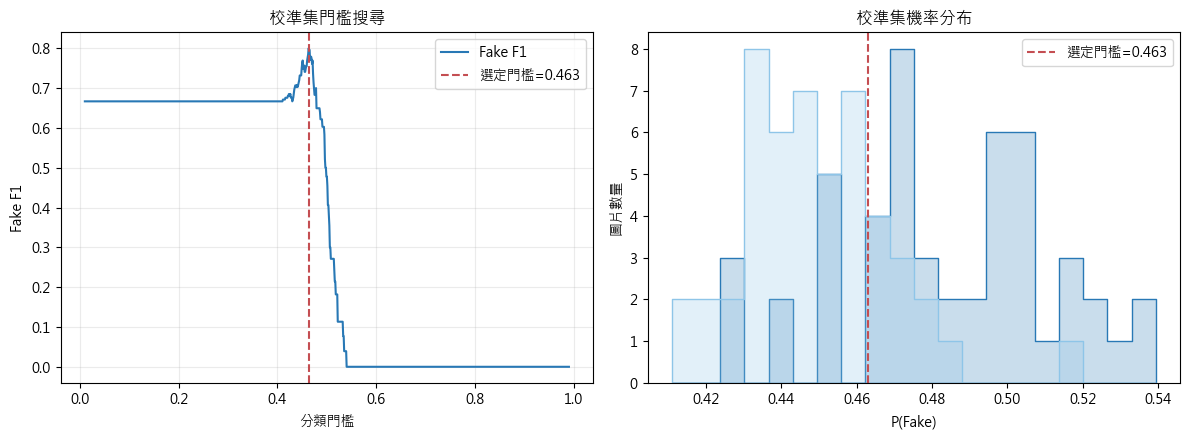

In [9]:
if calibration_predictions_df.empty or selected_threshold is None:
    print("尚未完成門檻校準。")
else:
    threshold_plot_df = threshold_search_df.sort_values("threshold")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(
        threshold_plot_df["threshold"],
        threshold_plot_df["f1"],
        color="#2878B5",
        label="Fake F1",
    )
    axes[0].axvline(
        selected_threshold,
        color="#C44E52",
        linestyle="--",
        label=f"選定門檻={selected_threshold:.3f}",
    )
    axes[0].set_xlabel("分類門檻")
    axes[0].set_ylabel("Fake F1")
    axes[0].set_title("校準集門檻搜尋")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    sns.histplot(
        data=calibration_predictions_df,
        x="fake_probability",
        hue="class_name",
        hue_order=["real", "fake"],
        bins=20,
        element="step",
        stat="count",
        common_norm=False,
        palette={"real": "#8EC5E8", "fake": "#2878B5"},
        ax=axes[1],
    )
    axes[1].axvline(
        selected_threshold,
        color="#C44E52",
        linestyle="--",
        label=f"選定門檻={selected_threshold:.3f}",
    )
    axes[1].set_xlabel("P(Fake)")
    axes[1].set_ylabel("圖片數量")
    axes[1].set_title("校準集機率分布")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(
        OUTPUT_ROOT / "calibration_threshold_analysis.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


## 10. 固定門檻後執行正式測試

門檻已選定，此處對獨立的 200 張測試圖片推論。結果不可再用來修改門檻。

In [10]:
formal_test_predictions_df = pd.DataFrame()
formal_metrics_comparison_df = pd.DataFrame()
formal_metrics = {}

if not RUN_FORMAL_TEST:
    print("RUN_FORMAL_TEST=False，尚未執行正式測試。")
elif selected_threshold is None:
    raise RuntimeError("尚未完成門檻校準，不能執行正式測試。")
else:
    formal_test_predictions_df = infer_dataset(
        model,
        formal_test_loader,
        "Formal Test Inference",
    )

    threshold_settings = {
        "original_0.5": ORIGINAL_THRESHOLD,
        "calibrated": selected_threshold,
    }
    comparison_records = []

    for setting_name, threshold in threshold_settings.items():
        prediction_column = f"prediction_{setting_name}"
        predicted_class_column = f"predicted_class_{setting_name}"
        correct_column = f"correct_{setting_name}"

        formal_test_predictions_df[prediction_column] = (
            formal_test_predictions_df["fake_probability"] >= threshold
        ).astype(int)
        formal_test_predictions_df[predicted_class_column] = (
            formal_test_predictions_df[prediction_column]
            .map({0: "real", 1: "fake"})
        )
        formal_test_predictions_df[correct_column] = (
            formal_test_predictions_df["label"]
            == formal_test_predictions_df[prediction_column]
        )

        metrics = binary_metrics(
            formal_test_predictions_df["label"],
            formal_test_predictions_df["fake_probability"],
            threshold,
        )
        formal_metrics[setting_name] = metrics
        comparison_records.append({
            "threshold_setting": setting_name,
            **metrics,
        })

        report_dict = classification_report(
            formal_test_predictions_df["label"],
            formal_test_predictions_df[prediction_column],
            labels=[0, 1],
            target_names=["Real", "Fake"],
            digits=4,
            zero_division=0,
            output_dict=True,
        )
        pd.DataFrame(report_dict).transpose().to_csv(
            OUTPUT_ROOT
            / f"classification_report_{setting_name}.csv",
            encoding="utf-8-sig",
        )

    formal_metrics_comparison_df = pd.DataFrame(comparison_records)
    formal_test_predictions_df.to_csv(
        OUTPUT_ROOT / "formal_test_predictions.csv",
        index=False,
        encoding="utf-8-sig",
    )
    formal_metrics_comparison_df.to_csv(
        OUTPUT_ROOT / "formal_test_metrics_comparison.csv",
        index=False,
        encoding="utf-8-sig",
    )

    result_payload = {
        "dataset": "Independent Mobile Formal Test",
        "method": "Full Forensics Adapter trained on FF++ Deepfakes",
        "checkpoint": str(BEST_MODEL_PATH.resolve()),
        "preprocessing": "YOLO face crop + 256x256 + CLIP mean/std",
        "label_mapping": LABEL_MAPPING,
        "threshold_selection": {
            "dataset": "separate mobile calibration set",
            "metric": "Fake F1",
            "selected_threshold": selected_threshold,
        },
        "formal_test_metrics": formal_metrics,
        "note": (
            "Formal test results were not used to select or adjust "
            "the calibrated threshold."
        ),
    }
    with (OUTPUT_ROOT / "formal_test_metrics.json").open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(result_payload, file, ensure_ascii=False, indent=2)

    display(formal_metrics_comparison_df)
    print(json.dumps(result_payload, ensure_ascii=False, indent=2))


Formal Test Inference:   0%|          | 0/50 [00:00<?, ?it/s]

,threshold_setting,sample_count,real_count,fake_count,predicted_fake_count,accuracy,precision,recall,specificity,f1,auc,threshold,tn,fp,fn,tp
0,original_0.5,200,100,100,12,0.560,1.000000,0.12,1.00,0.214286,0.82395,0.500,100,0,88,12
1,calibrated,200,100,100,85,0.745,0.788235,0.67,0.82,0.724324,0.82395,0.463,82,18,33,67


{
  "dataset": "Independent Mobile Formal Test",
  "method": "Full Forensics Adapter trained on FF++ Deepfakes",
  "checkpoint": "D:\\資料\\專題\\PY\\deepfake\\新版專題研究\\ForensicsAdapter_Results\\ffpp_original_deepfakes_full\\best_model.pth",
  "preprocessing": "YOLO face crop + 256x256 + CLIP mean/std",
  "label_mapping": {
    "real": 0,
    "fake": 1
  },
  "threshold_selection": {
    "dataset": "separate mobile calibration set",
    "metric": "Fake F1",
    "selected_threshold": 0.46299999999999963
  },
  "formal_test_metrics": {
    "original_0.5": {
      "sample_count": 200,
      "real_count": 100,
      "fake_count": 100,
      "predicted_fake_count": 12,
      "accuracy": 0.56,
      "precision": 1.0,
      "recall": 0.12,
      "specificity": 1.0,
      "f1": 0.21428571428571427,
      "auc": 0.82395,
      "threshold": 0.5,
      "tn": 100,
      "fp": 0,
      "fn": 88,
      "tp": 12
    },
    "calibrated": {
      "sample_count": 200,
      "real_count": 100,
      "fake_cou

## 11. 正式測試結果

| 門檻 | Accuracy | Precision | Recall | Specificity | F1 | AUC |
|---|---|---|---|---|---|---|
| 0.5（預設） | 0.560 | 1.000 | 0.120 | 1.000 | 0.214 | 0.824 |
| 0.463（校準） | 0.745 | 0.788 | 0.670 | 0.820 | 0.724 | 0.824 |

混淆矩陣的差異更直接：預設門檻下 100 張 Fake 只有 12 張被判出（TP 12、FN 88），沒有任何 Real 被誤判（FP 0）。校準後 TP 提升至 67，代價是 18 個 FP。

AUC 在兩種門檻下完全相同（0.824），因為 AUC 不受門檻影響。同一個模型、同一批機率，僅移動門檻 0.037，F1 從 0.214 變成 0.724。

左圖為預設門檻，右圖為校準門檻。ROC 曲線只需繪製一次。

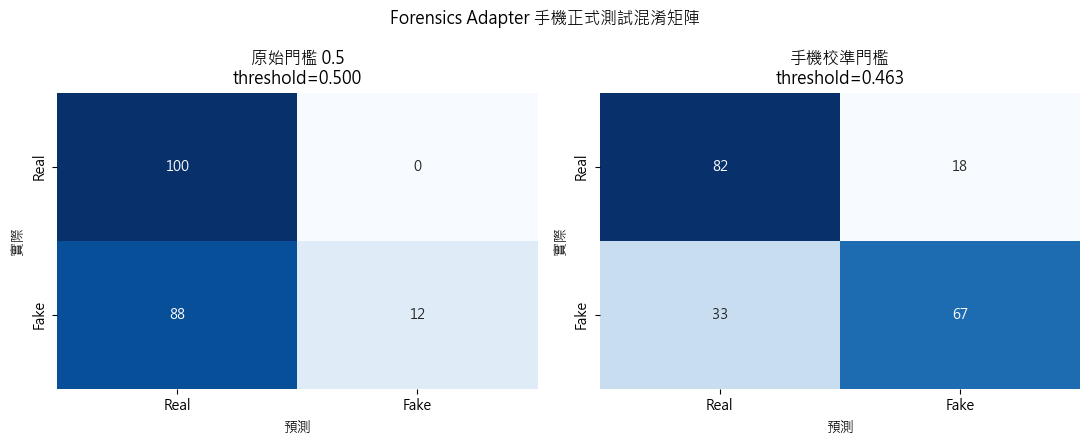

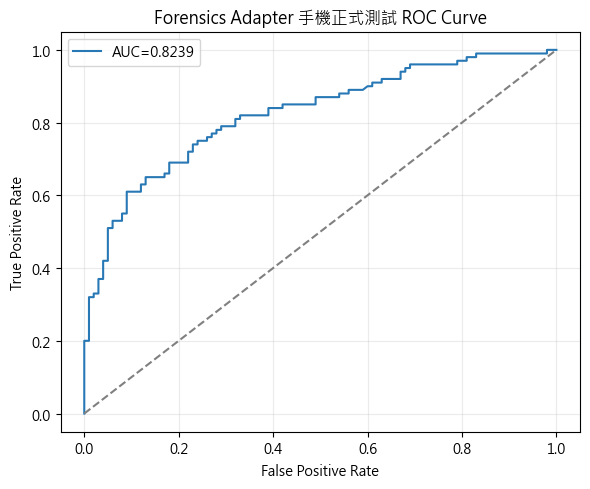

In [11]:
if formal_test_predictions_df.empty:
    print("尚未完成正式測試。")
else:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    plot_settings = [
        ("original_0.5", ORIGINAL_THRESHOLD, "原始門檻 0.5"),
        ("calibrated", selected_threshold, "手機校準門檻"),
    ]

    for axis, (setting_name, threshold, title) in zip(
        axes,
        plot_settings,
    ):
        prediction_column = f"prediction_{setting_name}"
        matrix = confusion_matrix(
            formal_test_predictions_df["label"],
            formal_test_predictions_df[prediction_column],
            labels=[0, 1],
        )
        sns.heatmap(
            matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"],
            ax=axis,
        )
        axis.set_title(f"{title}\nthreshold={threshold:.3f}")
        axis.set_xlabel("預測")
        axis.set_ylabel("實際")

    plt.suptitle("Forensics Adapter 手機正式測試混淆矩陣")
    plt.tight_layout()
    plt.savefig(
        OUTPUT_ROOT / "formal_test_confusion_matrices.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

    fpr, tpr, _ = roc_curve(
        formal_test_predictions_df["label"],
        formal_test_predictions_df["fake_probability"],
    )
    test_auc = safe_auc(
        formal_test_predictions_df["label"],
        formal_test_predictions_df["fake_probability"],
    )
    plt.figure(figsize=(6, 5))
    plt.plot(
        fpr,
        tpr,
        color="#2878B5",
        label=f"AUC={test_auc:.4f}",
    )
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Forensics Adapter 手機正式測試 ROC Curve")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(
        OUTPUT_ROOT / "formal_test_roc_curve.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


## 12. 匯出誤判案例

只整理正式測試結果，不再調整門檻。

In [12]:
if formal_test_predictions_df.empty:
    print("尚未完成正式測試。")
else:
    errors_df = formal_test_predictions_df[
        ~formal_test_predictions_df["correct_calibrated"]
    ].copy()
    errors_df["error_confidence"] = np.where(
        errors_df["prediction_calibrated"].eq(1),
        errors_df["fake_probability"],
        1.0 - errors_df["fake_probability"],
    )
    errors_df = errors_df.sort_values(
        "error_confidence",
        ascending=False,
    )
    errors_df.to_csv(
        OUTPUT_ROOT / "formal_test_error_cases_calibrated.csv",
        index=False,
        encoding="utf-8-sig",
    )
    print(f"校準門檻下的正式測試誤判：{len(errors_df)} 張")
    display(errors_df.head(20))


校準門檻下的正式測試誤判：51 張


,split,path,file_name,class_name,label,fake_probability,prediction_original_0.5,predicted_class_original_0.5,correct_original_0.5,prediction_calibrated,predicted_class_calibrated,correct_calibrated,error_confidence
26,test,D:\資料\專題\PY\deepfake\新版專題研究\dataset_mobile_spl...,fake_test_027.jpg,fake,1,0.412234,0,real,False,0,real,False,0.587766
6,test,D:\資料\專題\PY\deepfake\新版專題研究\dataset_mobile_spl...,fake_test_007.jpg,fake,1,0.427994,0,real,False,0,real,False,0.572006
86,test,D:\資料\專題\PY\deepfake\新版專題研究\dataset_mobile_spl...,fake_test_087.jpg,fake,1,0.429220,0,real,False,0,real,False,0.570780
54,test,D:\資料\專題\PY\deepfake\新版專題研究\dataset_mobile_spl...,fake_test_055.jpg,fake,1,0.431075,0,real,False,0,real,False,0.568925
89,test,D:\資料\專題\PY\deepfake\新版專題研究\dataset_mobile_spl...,fake_test_090.jpg,fake,1,0.437057,0,real,False,0,real,False,0.562943
42,test,D:\資料\專題\PY\deepfake\新版專題研究\dataset_mobile_spl...,fake_test_043.jpg,fake,1,0.437373,0,real,False,0,real,False,0.562627
70,test,D:\資料\專題\PY\deepfake\新版專題研究\dataset_mobile_spl...,fake_test_071.jpg,fake,1,0.440454,0,real,False,0,real,False,0.559546
9,test,D:\資料\專題\PY\deepfake\新版專題研究\dataset_mobile_spl...,fake_test_010.jpg,fake,1,0.440800,0,real,False,0,real,False,0.559200
27,test,D:\資料\專題\PY\deepfake\新版專題研究\dataset_mobile_spl...,fake_test_028.jpg,fake,1,0.442486,0,real,False,0,real,False,0.557514
34,test,D:\資料\專題\PY\deepfake\新版專題研究\dataset_mobile_spl...,fake_test_035.jpg,fake,1,0.444715,0,real,False,0,real,False,0.555285


## 結論

**主要發現**：在 FF++ 上訓練的模型，套用到訓練分布外的影像時，輸出機率整體壓縮並向 Real 側偏移。預設門檻 0.5 落在分布的極端位置，導致 recall 崩至 0.12——模型並非失去鑑別力（AUC 仍有 0.824），而是門檻不再位於合適的切分點。

僅需一組獨立的小規模校準資料（本例 100 張）重新選擇門檻，即可將 F1 從 0.214 提升至 0.724，完全不需重新訓練。

這與 04 和 08 在 HiDF、Celeb-DF v2 上觀察到的 recall 偏低、precision 偏高現象一致，且該現象在換用更強的方法後依然存在。**門檻校準是與模型能力相對獨立的部署問題**，強化模型並不能取代它。

**適用範圍**：本結論建立在機率分布形狀的觀察上，不依賴 AUC 的絕對數值。0.824 這個數字本身因資料蒐集方式（Real 手機實拍、Fake 網路蒐集）而不作為泛化能力的估計。

**實務意涵**：部署時應保留一組與目標場景相符的校準資料，並將門檻視為需要隨部署環境重新決定的參數，而非模型的固定屬性。`selected_threshold.json` 記錄了本次固定下來的門檻值。

輸出檔案：

```text
ForensicsAdapter_Results/
└── ffpp_original_deepfakes_mobile_threshold_calibration/
    ├── calibration_predictions.csv
    ├── threshold_search.csv
    ├── selected_threshold.json
    ├── formal_test_predictions.csv
    ├── formal_test_metrics_comparison.csv
    ├── formal_test_metrics.json
    ├── classification_report_original_0.5.csv
    ├── classification_report_calibrated.csv
    └── formal_test_error_cases_calibrated.csv
```